In [43]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
df = pd.read_csv('/content/drive/MyDrive/unemployment analysis.csv')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 33 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  235 non-null    object 
 1   Country Code  235 non-null    object 
 2   1991          235 non-null    float64
 3   1992          235 non-null    float64
 4   1993          235 non-null    float64
 5   1994          235 non-null    float64
 6   1995          235 non-null    float64
 7   1996          235 non-null    float64
 8   1997          235 non-null    float64
 9   1998          235 non-null    float64
 10  1999          235 non-null    float64
 11  2000          235 non-null    float64
 12  2001          235 non-null    float64
 13  2002          235 non-null    float64
 14  2003          235 non-null    float64
 15  2004          235 non-null    float64
 16  2005          235 non-null    float64
 17  2006          235 non-null    float64
 18  2007          235 non-null    

In [11]:
df.head()

,Country Name,Country Code,1991,1992,1993,1994,1995,1996,1997,1998,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Africa Eastern and Southern,AFE,7.80,7.84,7.85,7.84,7.83,7.84,7.86,7.81,...,6.56,6.45,6.41,6.49,6.61,6.71,6.73,6.91,7.56,8.11
1,Afghanistan,AFG,10.65,10.82,10.72,10.73,11.18,10.96,10.78,10.80,...,11.34,11.19,11.14,11.13,11.16,11.18,11.15,11.22,11.71,13.28
2,Africa Western and Central,AFW,4.42,4.53,4.55,4.54,4.53,4.57,4.60,4.66,...,4.64,4.41,4.69,4.63,5.57,6.02,6.04,6.06,6.77,6.84
3,Angola,AGO,4.21,4.21,4.23,4.16,4.11,4.10,4.09,4.07,...,7.35,7.37,7.37,7.39,7.41,7.41,7.42,7.42,8.33,8.53
4,Albania,ALB,10.31,30.01,25.26,20.84,14.61,13.93,16.88,20.05,...,13.38,15.87,18.05,17.19,15.42,13.62,12.30,11.47,13.33,11.82


In [16]:
#mengubah format ke wide
df_long=df.melt(
    id_vars='Country Name',
    var_name='year',
    value_name='unemployment_Rate'
)
df_long

,Country Name,year,unemployment_Rate
0,Africa Eastern and Southern,Country Code,AFE
1,Afghanistan,Country Code,AFG
2,Africa Western and Central,Country Code,AFW
3,Angola,Country Code,AGO
4,Albania,Country Code,ALB
...,...,...,...
7515,Samoa,2021,9.84
7516,"Yemen, Rep.",2021,13.57
7517,South Africa,2021,33.56
7518,Zambia,2021,13.03


In [22]:
#membuang baris yang bukan angka pada kolom year
df_clean = df_long[df_long['year'].str.isnumeric()]
df_clean

,Country Name,year,unemployment_Rate
235,Africa Eastern and Southern,1991,7.8
236,Afghanistan,1991,10.65
237,Africa Western and Central,1991,4.42
238,Angola,1991,4.21
239,Albania,1991,10.31
...,...,...,...
7515,Samoa,2021,9.84
7516,"Yemen, Rep.",2021,13.57
7517,South Africa,2021,33.56
7518,Zambia,2021,13.03


In [23]:
df_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7520 entries, 0 to 7519
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Country Name       7520 non-null   object
 1   year               7520 non-null   object
 2   unemployment_Rate  7520 non-null   object
dtypes: object(3)
memory usage: 176.4+ KB


In [26]:
#mengubah tipe data pada kolom year menjadi numeri
df_long['year'] = pd.to_numeric(df_long['year'],
                                errors='coerce')
df_long

,Country Name,year,unemployment_Rate
0,Africa Eastern and Southern,NaN,AFE
1,Afghanistan,NaN,AFG
2,Africa Western and Central,NaN,AFW
3,Angola,NaN,AGO
4,Albania,NaN,ALB
...,...,...,...
7515,Samoa,2021.0,9.84
7516,"Yemen, Rep.",2021.0,13.57
7517,South Africa,2021.0,33.56
7518,Zambia,2021.0,13.03


In [28]:
#konversi unemploymeny _Rate ke numeric
df_long['unemployment_Rate']=pd.to_numeric(
    df_long['unemployment_Rate'],errors='coerce'
)
df_long

,Country Name,year,unemployment_Rate
0,Africa Eastern and Southern,NaN,NaN
1,Afghanistan,NaN,NaN
2,Africa Western and Central,NaN,NaN
3,Angola,NaN,NaN
4,Albania,NaN,NaN
...,...,...,...
7515,Samoa,2021.0,9.84
7516,"Yemen, Rep.",2021.0,13.57
7517,South Africa,2021.0,33.56
7518,Zambia,2021.0,13.03


In [30]:
df_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7520 entries, 0 to 7519
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country Name       7520 non-null   object 
 1   year               7285 non-null   float64
 2   unemployment_Rate  7285 non-null   float64
dtypes: float64(2), object(1)
memory usage: 176.4+ KB


In [29]:
#membuang baris yang masing tidak valid
df_clean=df_long.dropna(subset=['year','unemployment_Rate'])
df_clean

,Country Name,year,unemployment_Rate
235,Africa Eastern and Southern,1991.0,7.80
236,Afghanistan,1991.0,10.65
237,Africa Western and Central,1991.0,4.42
238,Angola,1991.0,4.21
239,Albania,1991.0,10.31
...,...,...,...
7515,Samoa,2021.0,9.84
7516,"Yemen, Rep.",2021.0,13.57
7517,South Africa,2021.0,33.56
7518,Zambia,2021.0,13.03


In [32]:
#merapikan nomor index
df_clean=df_clean.reset_index(drop=True)
df_clean

,Country Name,year,unemployment_Rate
0,Africa Eastern and Southern,1991.0,7.80
1,Afghanistan,1991.0,10.65
2,Africa Western and Central,1991.0,4.42
3,Angola,1991.0,4.21
4,Albania,1991.0,10.31
...,...,...,...
7280,Samoa,2021.0,9.84
7281,"Yemen, Rep.",2021.0,13.57
7282,South Africa,2021.0,33.56
7283,Zambia,2021.0,13.03


In [40]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7285 entries, 0 to 7284
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country Name       7285 non-null   object 
 1   year               7285 non-null   float64
 2   unemployment_Rate  7285 non-null   float64
dtypes: float64(2), object(1)
memory usage: 170.9+ KB


In [42]:
global_trend =(
    df_clean.groupby('year')['unemployment_Rate'].mean().reset_index())
global_trend

,year,unemployment_Rate
0,1991.0,7.278000
1,1992.0,7.626340
2,1993.0,8.070766
3,1994.0,8.246043
4,1995.0,8.333915
5,1996.0,8.494894
6,1997.0,8.394043
7,1998.0,8.441064
8,1999.0,8.568043
9,2000.0,8.438979


dari data yang kita dapatkan di atas dapat terlihat jika rata rata tingkat pengangguran global menunjukkan pola fluktiatif sepanjang 1991-2021. periode awal (1991-2005) cenderung mengalami peningkatan, diikuti dengan penurunan pada pertengahan 2000-an. setelah itu, tingkat pengangguran berfuktuasi hingga 2021, yang mendidentifikasikan adanya pengaruh ekonomi global yang berada di setiap periode.

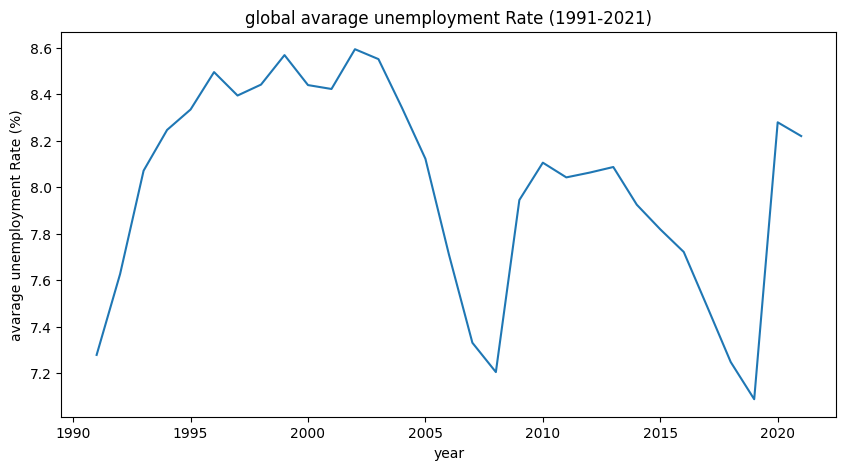

In [44]:
plt.figure(figsize=(10,5))
plt.plot(global_trend['year'],global_trend['unemployment_Rate'])
plt.xlabel('year')
plt.ylabel('avarage unemployment Rate (%)')
plt.title('global avarage unemployment Rate (1991-2021)')
plt.show()

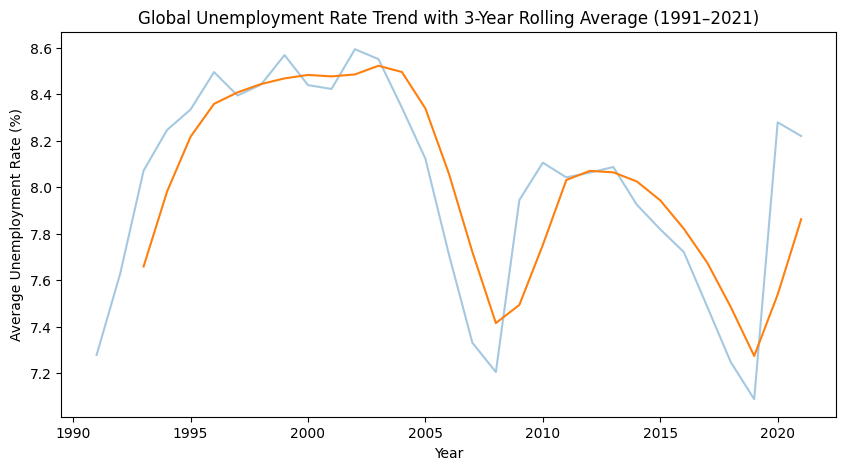

In [45]:
global_trend['rolling_avg'] = global_trend['unemployment_Rate'].rolling(window=3).mean()

plt.figure(figsize=(10,5))
plt.plot(global_trend['year'], global_trend['unemployment_Rate'], alpha=0.4)
plt.plot(global_trend['year'], global_trend['rolling_avg'])
plt.xlabel('Year')
plt.ylabel('Average Unemployment Rate (%)')
plt.title('Global Unemployment Rate Trend with 3-Year Rolling Average (1991–2021)')
plt.show()


lanjut kita akan membuat perbandingan unemployment di negara maju dan berkembang

In [48]:
developed_countries = [
    'United States', 'Canada', 'Germany', 'France', 'United Kingdom',
    'Japan', 'Australia', 'New Zealand', 'South Korea',
    'Italy', 'Spain', 'Netherlands', 'Sweden', 'Norway',
    'Switzerland', 'Denmark', 'Finland', 'Belgium', 'Austria'
]
developed_countries

['United States',
 'Canada',
 'Germany',
 'France',
 'United Kingdom',
 'Japan',
 'Australia',
 'New Zealand',
 'South Korea',
 'Italy',
 'Spain',
 'Netherlands',
 'Sweden',
 'Norway',
 'Switzerland',
 'Denmark',
 'Finland',
 'Belgium',
 'Austria']

In [52]:
df_clean['country_group'] = df_clean['Country Name'].apply(
    lambda x: 'negara maju' if x in developed_countries else 'negara berkembang'
)

df_clean['country_group'].value_counts()


,count
country_group,
negara berkembang,6727
negara maju,558


In [53]:
df_recent = df_clean[df_clean['year'] >= 2015]

In [54]:
comparison = (
    df_recent
    .groupby('country_group')['unemployment_Rate']
    .mean()
    .reset_index()
)

comparison


,country_group,unemployment_Rate
0,negara berkembang,7.794253
1,negara maju,6.485476


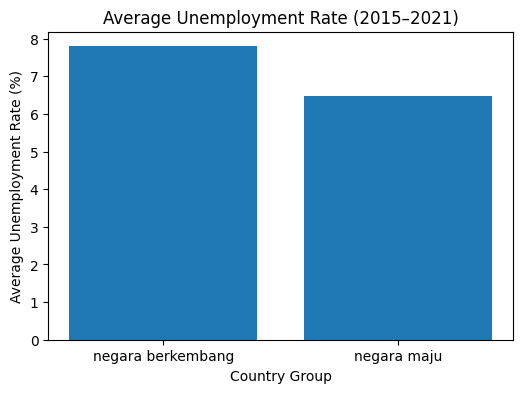

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(comparison['country_group'], comparison['unemployment_Rate'])
plt.xlabel('Country Group')
plt.ylabel('Average Unemployment Rate (%)')
plt.title('Average Unemployment Rate (2015–2021)')
plt.show()


dari data grafik di atas bisa dilihat jika negara maju menunjukkan tingkat oengangguran yang relatif lebih stabil, sementara negara berkembang emngalami fluktuatif yang lebih besar, yang mengidentifikasi kerentanan terhadap guncangan ekonomi global.